In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "visualization" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from ppm.wandb_utils import load_multiple_experiments

plots_dir = PROJECT_ROOT / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
PROJECTS = [
    "BPI12_lrz_001_003",
    "BPI19_lrz_002_002",
    "BPI17_lrz_002_002",
    "BPI15_lrz_002_001",
    "BPI17_spark_002_002",
    "BPI20_lrz_002_002",
    "BPI17_spark_002_001",
    "BPI12_spark_002_003",
    "BPI20_RFP_lrz_002",
    "BPI12_spark_002_002",
    "BPI20_PTC_lrz_002",
    "BPI19_lrz_002",
    "BPI15_lrz_002",
    "BPI12_spark_002",
    "BPI20_TPD_spark_001",
    "BPI17_lrz_002",
    "BPI20_PTC_spark_001",
    "BPI19_lrz_001",
    "BPI15_lrz_001",
    "BPI20_TPD_lrz_001",
    "BPI20_RFP_lrz_001",
    "BPI20_PTC_lrz_001",
    "lstm_bpi12_size100_layers3_001",
    "BPI17_lrz_001",
    "BPI12_lrz_001",
    "LSTM_001"
    "baseline-nep",

]

runs, _ = load_multiple_experiments(PROJECTS, force_update=False)


NameError: name 'load_multiple_experiments' is not defined

In [4]:
# These are the projects for which we did not save the best weights
NON_RECORDED_PROJECTS = [
    "BPI20_RFP_lrz_002",
    "BPI20_PTC_lrz_002",
    "BPI19_lrz_002",
    "BPI15_lrz_002",
    "BPI12_spark_002",
    "BPI20_TPD_spark_001",
    "BPI17_lrz_002",
    "BPI20_PTC_spark_001",
    "BPI19_lrz_001",
    "BPI15_lrz_001",
    "BPI20_TPD_lrz_001",
    "BPI20_RFP_lrz_001",
    "BPI20_PTC_lrz_001",
    "lstm_bpi12_size100_layers3_001",
    "BPI17_lrz_001",
    "BPI12_lrz_001",
    "baseline-nep",

]



In [5]:
runs["best_test_final_next_activity_f1"] = (
    runs["best_test_final_next_activity_f1"]
    .combine_first(runs["best_test_final_next_activity_f1_macro"])
)
runs = runs.drop(columns=["best_test_final_next_activity_f1_macro"])


In [5]:
runs.columns

Index(['id', 'name', 'r', 'lr', 'log', 'device', 'epochs', 'compile',
       'backbone', 'n_layers', 'patience', 'rnn_type', 'strategy', 'val_size',
       'grad_clip', 'lifecycle', 'min_delta', 'precision', 'val_split',
       'batch_size', 'lora_alpha', 'fine_tuning', 'hidden_size', 'num_workers',
       'total_params', 'weight_decay', 'freeze_layers', 'embedding_size',
       'trainable_params', 'continuous_targets', 'categorical_targets',
       'continuous_features', 'categorical_features', 'memory_safety_margin',
       'time_positional_encoding', 'duration_sec', 'best_test_final_loss',
       'best_test_final_next_activity_acc', 'best_test_final_next_activity_f1',
       'best_test_final_next_activity_loss', 'dataset/filtered_dataset_cases',
       'dataset/filtered_dataset_end', 'dataset/filtered_dataset_events',
       'dataset/filtered_dataset_max_duration_days',
       'dataset/filtered_dataset_start', 'dataset/orig_dataset_cases',
       'dataset/orig_dataset_end', 'dataset

## Print overview experiments
### -> Metric can be from ["best_test_final_next_activity_f1", "best_test_final_next_activity_acc"]

In [6]:
METRIC = "best_test_final_next_activity_acc"
#METRIC = "best_test_final_next_activity_f1"

for col in ["categorical_features", "continuous_features"]:
    if col in runs.columns:
        runs[col] = runs[col].astype(str)

GROUP_COLS = ["log", "backbone", "lr", "batch_size", "categorical_features", "continuous_features"]

EXTRA_COLS = ["project", "total_params", "trainable_params", "embedding_size"]
EXTRA_COLS = [c for c in EXTRA_COLS if c in runs.columns]  # only keep ones that exist

# Build df with everything we need
df = runs[GROUP_COLS + ["id", METRIC] + EXTRA_COLS].dropna(subset=[METRIC]).copy()
df[METRIC] = df[METRIC].astype(float)

# 1) Metric stats (ONLY from METRIC)
agg = (
    df.groupby(GROUP_COLS)[METRIC]
      .agg(["count", "mean", "std", "min", "max"])
      .rename(columns={
          "count": "n_runs",
          "mean": "acc_mean",
          "std": "acc_std",
          "min": "acc_min",
          "max": "acc_max",
      })
)

# 2) Add “descriptor” columns (not metric-related)
#    We assume these are constant within group; if not, we’ll detect it below.
descriptors = df.groupby(GROUP_COLS)[EXTRA_COLS].first() if EXTRA_COLS else None

# Optional: detect groups where descriptors are NOT constant
if EXTRA_COLS:
    nunique = df.groupby(GROUP_COLS)[EXTRA_COLS].nunique(dropna=False)
    bad = (nunique > 1).any(axis=1)
    if bad.any():
        print("Warning: some groups have varying descriptor values:")
        display(nunique[bad].reset_index())

# 3) Best run id per group (based on METRIC)
best_idx = df.groupby(GROUP_COLS)[METRIC].idxmax()
best_runs = df.loc[best_idx].set_index(GROUP_COLS)["id"].rename("best_run_id")

# 4) Combine
summary = agg
if descriptors is not None:
    summary = summary.join(descriptors)

summary = summary.join(best_runs).reset_index()
summary["n_runs"] = summary["n_runs"].astype(int)

for col in ["acc_mean", "acc_std", "acc_min", "acc_max"]:
    summary[col] = summary[col].map(lambda x: f"{x:.4f}")

summary = summary.sort_values(GROUP_COLS).reset_index(drop=True)

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 200):
    display(summary)


,log,backbone,lr,batch_size,categorical_features,continuous_features,project,total_params,trainable_params,embedding_size
0,BPI12,gpt2,0.00500,64.0,['activity'],['accumulated_time'],2,1,1,2
1,BPI12,gpt2-mini,0.00500,64.0,['activity'],['accumulated_time'],1,1,1,2
2,BPI12,qwen3-0.6b,0.00005,64.0,['activity'],['accumulated_time'],2,1,1,1
3,BPI12,qwen3-0.6b,0.00050,64.0,['activity'],['accumulated_time'],2,1,1,1
4,BPI12,qwen3-0.6b,0.00500,64.0,['activity'],['accumulated_time'],2,1,1,1
5,BPI12,qwen3-1.7b,0.00005,64.0,['activity'],['accumulated_time'],2,1,1,1
6,BPI12,qwen3-1.7b,0.00050,64.0,['activity'],['accumulated_time'],2,1,1,1
7,BPI12,qwen3-1.7b,0.00500,64.0,['activity'],['accumulated_time'],2,1,1,1
8,BPI12,qwen3-4b,0.00005,64.0,['activity'],['accumulated_time'],2,1,1,1
9,BPI12,qwen3-4b,0.00050,64.0,['activity'],['accumulated_time'],2,1,1,1


,log,backbone,lr,batch_size,categorical_features,continuous_features,n_runs,acc_mean,acc_std,acc_min,acc_max,project,total_params,trainable_params,embedding_size,best_run_id
0,BPI12,gpt2,0.00005,64.0,['activity'],['accumulated_time'],8,0.7192,0.0240,0.6877,0.7611,BPI12_lrz_001,1.245044e+08,64551.0,NaN,c947ecdg
1,BPI12,gpt2,0.00050,64.0,['activity'],['accumulated_time'],5,0.8020,0.0169,0.7728,0.8155,BPI12_lrz_001,1.245044e+08,64551.0,NaN,jyb5k3cq
2,BPI12,gpt2,0.00500,64.0,['activity'],['accumulated_time'],15,0.8154,0.0094,0.8023,0.8314,BPI12_spark_002_003,1.245044e+08,64551.0,768.0,pkjmgoop
3,BPI12,gpt2-large,0.00005,64.0,['activity'],['accumulated_time'],6,0.7808,0.0264,0.7378,0.8061,BPI12_lrz_001,7.741376e+08,107559.0,NaN,qv5du45c
4,BPI12,gpt2-large,0.00050,64.0,['activity'],['accumulated_time'],5,0.7796,0.0458,0.7032,0.8199,BPI12_lrz_001,7.741376e+08,107559.0,NaN,8cc7im30
5,BPI12,gpt2-large,0.00500,64.0,['activity'],['accumulated_time'],5,0.7989,0.0111,0.7877,0.8118,BPI12_lrz_001,7.741376e+08,107559.0,NaN,s41y38iv
6,BPI12,gpt2-medium,0.00005,64.0,['activity'],['accumulated_time'],6,0.5249,0.2223,0.0792,0.6751,BPI12_lrz_001,3.549092e+08,86055.0,NaN,ig5x2z3i
7,BPI12,gpt2-medium,0.00050,64.0,['activity'],['accumulated_time'],5,0.7457,0.0503,0.6967,0.8304,BPI12_lrz_001,3.549092e+08,86055.0,NaN,512b6mnw
8,BPI12,gpt2-medium,0.00500,64.0,['activity'],['accumulated_time'],5,0.7458,0.0537,0.6676,0.8025,BPI12_lrz_001,3.549092e+08,86055.0,NaN,a56yup1h
9,BPI12,gpt2-mini,0.00005,64.0,['activity'],['accumulated_time'],8,0.7598,0.0452,0.6939,0.8200,BPI12_lrz_001,3.864734e+07,43047.0,NaN,jxt1xv0n


## Print list with TO DOs (missing experiments). Best is selected based on val_loss

In [7]:
import numpy as np
import pandas as pd

# ============================================================
# PREP (your filters)
# ============================================================
runs_clean = runs[runs["log"] != "rnn"].copy()
runs_clean = runs_clean[runs_clean["lr"] != 0.0001].copy()

log_list = runs_clean["log"].unique()
backbone_list = runs_clean["backbone"].unique()
lr_list = runs_clean["lr"].unique()

# ============================================================
# CONFIG
# ============================================================
METRIC = "val_loss"  # change if needed

TARGET_N_RUNS_DEFAULT = 5
SPECIAL_BACKBONE = "baseline_transition_frequency"
SPECIAL_TARGET_N_RUNS = 1

BASE3 = ["log", "backbone", "lr"]
REST = ["batch_size", "categorical_features", "continuous_features"]
GROUP6 = BASE3 + REST

metric_prefix = "loss"  # used for naming summary stats columns

# If EXTRA_COLS contains "project", we'll remove it to avoid duplicate/confusing columns
if "EXTRA_COLS" in globals() and EXTRA_COLS:
    EXTRA_COLS = [c for c in EXTRA_COLS if c != "project"]

# Sanity: ensure required cols exist
required_cols = set(GROUP6 + ["id", METRIC, "project"])
missing_required = required_cols - set(runs_clean.columns)
if missing_required:
    raise KeyError(f"runs_clean is missing required columns: {sorted(missing_required)}")

# ============================================================
# BUILD df_full (ONLY rows with metric present)
# ============================================================
# GROUP_COLS is often the same as GROUP6, but use GROUP6 directly for safety
cols_to_take = GROUP6 + ["project", "id", METRIC] + (EXTRA_COLS if ("EXTRA_COLS" in globals() and EXTRA_COLS) else [])
df_full = runs_clean[cols_to_take].dropna(subset=[METRIC]).copy()
df_full[METRIC] = df_full[METRIC].astype(float)

# Normalize merge-key dtypes (string is safest across NaNs/mixed types)
for c in ["batch_size", "categorical_features", "continuous_features", "lr"]:
    if c in df_full.columns:
        df_full[c] = df_full[c].astype(str)

# ============================================================
# METRIC STATS per GROUP6
# ============================================================
agg6 = (
    df_full.groupby(GROUP6)[METRIC]
      .agg(["count", "mean", "std", "min", "max"])
      .rename(columns={
          "count": "n_runs",
          "mean": f"{metric_prefix}_mean",
          "std": f"{metric_prefix}_std",
          "min": f"{metric_prefix}_min",
          "max": f"{metric_prefix}_max",
      })
)

# NEW: list ALL projects that contributed to each group
projects6 = (
    df_full.groupby(GROUP6)["project"]
      .agg(lambda s: ", ".join(sorted(pd.unique(s.astype(str)))))
      .rename("projects")
)

# Optional extra descriptors (first row in group)
descriptors6 = df_full.groupby(GROUP6)[EXTRA_COLS].first() if ("EXTRA_COLS" in globals() and EXTRA_COLS) else None

# Best run id for this group (MIN val_loss)
best_idx6 = df_full.groupby(GROUP6)[METRIC].idxmin()
best_runs6 = df_full.loc[best_idx6].set_index(GROUP6)["id"].rename("best_run_id")

# Assemble summary
summary6 = agg6.join(projects6).join(best_runs6)
if descriptors6 is not None:
    summary6 = summary6.join(descriptors6)
summary6 = summary6.reset_index()

# Normalize merge keys in summary too
for c in ["batch_size", "categorical_features", "continuous_features", "lr"]:
    if c in summary6.columns:
        summary6[c] = summary6[c].astype(str)

# ============================================================
# BUILD GRID with special-case backbone (your original logic)
# ============================================================
log_list_s = [str(x) for x in pd.Index(log_list)]
backbone_list_s = [str(x) for x in pd.Index(backbone_list)]

# IMPORTANT: exclude NaN from lr for ALL normal backbones
lr_list_non_nan_s = [str(x) for x in pd.Index(lr_list) if not pd.isna(x) and str(x) != "nan"]

normal_backbones = [b for b in backbone_list_s if b != SPECIAL_BACKBONE]
special_backbones = [b for b in backbone_list_s if b == SPECIAL_BACKBONE]

grid_normal = pd.MultiIndex.from_product(
    [log_list_s, normal_backbones, lr_list_non_nan_s],
    names=BASE3
).to_frame(index=False)

# Special backbone ONLY gets lr == nan
if special_backbones:
    grid_special = pd.MultiIndex.from_product(
        [log_list_s, special_backbones, ["nan"]],
        names=BASE3
    ).to_frame(index=False)
    grid3 = pd.concat([grid_normal, grid_special], ignore_index=True)
else:
    grid3 = grid_normal

# Variants observed in data
variants = df_full[GROUP6].drop_duplicates()

# Enforce rule in variants too: remove lr == "nan" rows for non-special backbones
variants = variants[
    (variants["backbone"].astype(str) == SPECIAL_BACKBONE) | (variants["lr"].astype(str) != "nan")
].copy()

# Ensure every (log, backbone, lr) appears at least once; add placeholders if missing
missing_base3 = grid3.merge(
    variants[BASE3].drop_duplicates(),
    on=BASE3,
    how="left",
    indicator=True
)
missing_base3 = missing_base3[missing_base3["_merge"] == "left_only"][BASE3]

MISSING_TOKEN = "__MISSING__"
if len(missing_base3) > 0:
    placeholders = missing_base3.copy()
    for c in REST:
        placeholders[c] = MISSING_TOKEN
    variants = pd.concat([variants, placeholders[GROUP6]], ignore_index=True)

full_grid6 = grid3.merge(variants, on=BASE3, how="left")[GROUP6].drop_duplicates()

# dtype safety
for c in ["batch_size", "categorical_features", "continuous_features", "lr"]:
    if c in full_grid6.columns:
        full_grid6[c] = full_grid6[c].astype(str)

# ============================================================
# JOIN GRID + SUMMARY
# ============================================================
out = full_grid6.merge(summary6, on=GROUP6, how="left")

# Missing row marker
out["_missing_row"] = out["n_runs"].isna()

# Fill stats
out["n_runs"] = out["n_runs"].fillna(0).astype(int)
out["best_run_id"] = out["best_run_id"].fillna("")
out["projects"] = out["projects"].fillna("")

# ============================================================
# Missing runs to reach 10 for BEST (log, backbone) row
# For val_loss: BEST = MIN mean
# ============================================================
TARGET_FOR_BEST = 10
mean_col = f"{metric_prefix}_mean"  # loss_mean

# Ensure numeric for ranking
out["_mean_num"] = pd.to_numeric(out[mean_col], errors="coerce")

g = out.groupby(["log", "backbone"])["_mean_num"]
has_any = g.transform("count") > 0  # count excludes NaNs

best_idx_lb = (
    out.loc[has_any]
       .groupby(["log", "backbone"])["_mean_num"]
       .idxmin()
)

out["missing_to_10_best"] = 0
out.loc[best_idx_lb, "missing_to_10_best"] = (
    (TARGET_FOR_BEST - out.loc[best_idx_lb, "n_runs"])
    .clip(lower=0)
    .astype(int)
)

# Cleanup helper
out = out.drop(columns=["_mean_num"])

# Clear EXTRA_COLS for missing rows (optional; keep projects visible even when missing)
if "EXTRA_COLS" in globals() and EXTRA_COLS:
    for c in EXTRA_COLS:
        if c in out.columns:
            out[c] = out[c].where(~out["_missing_row"], "")

# Per-row target n_runs (special backbone needs only 1)
out["_target_n_runs"] = np.where(
    out["backbone"].astype(str) == SPECIAL_BACKBONE,
    SPECIAL_TARGET_N_RUNS,
    TARGET_N_RUNS_DEFAULT
)

out["missing_runs"] = (out["_target_n_runs"] - out["n_runs"]).clip(lower=0).astype(int)

# Format metric stats
metric_cols = [f"{metric_prefix}_mean", f"{metric_prefix}_std", f"{metric_prefix}_min", f"{metric_prefix}_max"]
for col in metric_cols:
    if col in out.columns:
        out[col] = out[col].map(lambda x: "" if pd.isna(x) else f"{float(x):.4f}")

out = out.sort_values(GROUP6).reset_index(drop=True)


# ------------------------------------------------------------
# GREEN ROW: best val_loss per log, only if n_runs >= 4
# ------------------------------------------------------------
mean_col = f"{metric_prefix}_mean"

out["_mean_num"] = pd.to_numeric(out[mean_col], errors="coerce")

eligible = out["n_runs"] >= 4

best_idx_per_log = (
    out.loc[eligible]
       .groupby("log")["_mean_num"]
       .idxmin()
)

out["_is_best_log"] = False
out.loc[best_idx_per_log, "_is_best_log"] = True



# ============================================================
# STYLING
# ============================================================
def _row_red(s):
    return ["color: red"] * len(s) if bool(out.loc[s.name, "_missing_row"]) else [""] * len(s)

def _missing_runs_red(v):
    try:
        return "color: red" if int(v) > 0 else ""
    except Exception:
        return ""
    
def _row_green(s):
    return ["background-color: #e6ffe6"] * len(s) if bool(out.loc[s.name, "_is_best_log"]) else [""] * len(s)


# Drop helper cols from display (older pandas-friendly)
out_display = out.drop(columns=["_missing_row", "_target_n_runs", "_is_best_log", "_mean_num"])

styled = (
    out_display.style
      .set_properties(**{"color": "inherit"})
      .apply(_row_green, axis=1)      # ← green highlight
      .apply(_row_red, axis=1)        # ← red text for missing rows
      .map(_missing_runs_red, subset=["missing_runs"])
      .map(_missing_runs_red, subset=["missing_to_10_best"])
)

styled


,log,backbone,lr,batch_size,categorical_features,continuous_features,n_runs,loss_mean,loss_std,loss_min,loss_max,projects,best_run_id,total_params,trainable_params,embedding_size,missing_to_10_best,missing_runs
0,BPI12,baseline_transition_frequency,nan,__MISSING__,__MISSING__,__MISSING__,0,,,,,,,,,,0,1
1,BPI12,gpt2,0.0005,64.0,['activity'],['accumulated_time'],5,0.6320,0.0579,0.5776,0.7067,BPI12_lrz_001,pzfsftmt,124504359.000000,64551.000000,nan,0,0
2,BPI12,gpt2,0.005,64.0,['activity'],['accumulated_time'],25,0.5885,0.0477,0.5172,0.6659,"BPI12_lrz_001, BPI12_lrz_001_003, BPI12_spark_002_003",rw07da6o,124504359.000000,64551.000000,768.000000,0,0
3,BPI12,gpt2,5e-05,64.0,['activity'],['accumulated_time'],8,0.7045,0.0365,0.6603,0.7493,BPI12_lrz_001,c947ecdg,124504359.000000,64551.000000,nan,0,0
4,BPI12,gpt2-large,0.0005,64.0,['activity'],['accumulated_time'],5,0.7419,0.1453,0.5826,0.9633,BPI12_lrz_001,8cc7im30,774137639.000000,107559.000000,nan,0,0
5,BPI12,gpt2-large,0.005,64.0,['activity'],['accumulated_time'],5,0.7180,0.0855,0.5947,0.8233,BPI12_lrz_001,9fx0jpek,774137639.000000,107559.000000,nan,5,0
6,BPI12,gpt2-large,5e-05,64.0,['activity'],['accumulated_time'],6,0.7584,0.1039,0.5935,0.8692,BPI12_lrz_001,qv5du45c,774137639.000000,107559.000000,nan,0,0
7,BPI12,gpt2-medium,0.0005,64.0,['activity'],['accumulated_time'],5,0.8539,0.2056,0.4992,1.0218,BPI12_lrz_001,512b6mnw,354909223.000000,86055.000000,nan,5,0
8,BPI12,gpt2-medium,0.005,64.0,['activity'],['accumulated_time'],5,0.9192,0.2179,0.6301,1.1370,BPI12_lrz_001,a56yup1h,354909223.000000,86055.000000,nan,0,0
9,BPI12,gpt2-medium,5e-05,64.0,['activity'],['accumulated_time'],6,1.7410,0.8238,1.0490,3.3522,BPI12_lrz_001,ig5x2z3i,354909223.000000,86055.000000,nan,0,0


In [8]:
globals()

{'__name__': '__main__',
 '__doc__': 'Automatically created module for IPython interactive environment',
 '__package__': None,
 '__loader__': None,
 '__spec__': None,
 '__builtin__': <module 'builtins' (built-in)>,
 '__builtins__': <module 'builtins' (built-in)>,
 '_ih': ['',
  'import sys\nfrom pathlib import Path\n\nPROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "visualization" else Path.cwd()\nif str(PROJECT_ROOT) not in sys.path:\n    sys.path.insert(0, str(PROJECT_ROOT))\n\nimport pandas as pd\nfrom ppm.wandb_utils import load_multiple_experiments\n\nplots_dir = PROJECT_ROOT / "plots"\nplots_dir.mkdir(parents=True, exist_ok=True)',
  'PROJECTS = [\n    "BPI12_lrz_001_003",\n    "BPI19_lrz_002_002",\n    "BPI17_lrz_002_002",\n    "BPI15_lrz_002_001",\n    "BPI17_spark_002_002",\n    "BPI20_lrz_002_002",\n    "BPI17_spark_002_001",\n    "BPI12_spark_002_003",\n    "BPI20_RFP_lrz_002",\n    "BPI12_spark_002_002",\n    "BPI20_PTC_lrz_002",\n    "BPI19_lrz_002",\n    "BPI15_lrz

In [9]:
# ============================================================
# Count runs from RECORDED projects for each white line
# ============================================================

print(f"NON_RECORDED_PROJECTS: {NONREC}")
print(f"Normalized: {NONREC_NORM}")
print("\n" + "=" * 100 + "\n")

# For each white line, count how many runs come from projects NOT in NON_RECORDED_PROJECTS
white_lines_analysis = []

for idx, row in white_lines.iterrows():
    # Get the GROUP6 values for this white line
    group6_dict = row.to_dict()
    
    # Filter runs_clean to this exact GROUP6 combination
    mask = pd.Series(True, index=runs_clean.index)
    for col in GROUP6:
        mask &= (runs_clean[col] == group6_dict[col])
    
    matching_all = runs_clean[mask].copy()
    
    # Normalize project column
    matching_all["_proj_norm"] = matching_all["project"].astype(str).str.strip()
    
    # DEBUG: Show what we're comparing
    if group6_dict["log"] == "BPI12":
        print(f"\n=== DEBUG for BPI12 ===")
        print(f"Total matching rows: {len(matching_all)}")
        print(f"Unique projects found: {matching_all['project'].unique()}")
        print(f"Normalized projects: {matching_all['_proj_norm'].unique()}")
        print(f"NON_RECORDED (normalized): {NONREC_NORM}")
        print(f"Is 'BPI12_spark_002_003' in NONREC_NORM? {'BPI12_spark_002_003' in NONREC_NORM}")
        print(f"Projects NOT in NONREC_NORM:")
        for proj in matching_all['_proj_norm'].unique():
            is_recorded = proj not in NONREC_NORM
            print(f"  {proj}: recorded={is_recorded}")
    
    # Count total runs
    total_runs = len(matching_all)
    
    # Count runs from RECORDED projects (NOT in NON_RECORDED_PROJECTS)
    recorded_mask = ~matching_all["_proj_norm"].isin(NONREC_NORM)
    recorded_runs = recorded_mask.sum()
    
    # Get list of projects
    all_projects = sorted(matching_all["project"].unique())
    recorded_projects = sorted(matching_all[recorded_mask]["project"].unique())
    
    # Missing to reach 10 recorded runs
    missing_to_10 = max(0, 10 - recorded_runs)
    
    white_lines_analysis.append({
        "log": group6_dict["log"],
        "backbone": group6_dict["backbone"],
        "lr": group6_dict["lr"],
        "batch_size": group6_dict["batch_size"],
        "total_runs": total_runs,
        "recorded_runs": recorded_runs,
        "missing_to_10": missing_to_10,
        "all_projects": ", ".join(all_projects),
        "recorded_projects": ", ".join(recorded_projects)
    })

white_lines_df = pd.DataFrame(white_lines_analysis)

white_lines_df

NameError: name 'NONREC' is not defined

In [ ]:
cols = ['val_loss', 'val_next_activity_loss']

counts = pd.DataFrame({
    "nan_count": runs[cols].isna().sum(),
    "real_count": runs[cols].notna().sum(),
})
print(counts)

print(runs['val_loss'].equals(runs['val_next_activity_loss']))


                        nan_count  real_count
val_loss                       15         797
val_next_activity_loss         15         797
True


In [ ]:
runs[runs["id"] == "jyb5k3cq"].best_test_final_next_activity_f1

738    0.666564
Name: best_test_final_next_activity_f1, dtype: float64

In [ ]:
import json
import pandas as pd

METRICS = {
    "best_test_final_next_activity_acc": "acc",
    "best_test_final_next_activity_f1": "f1",
}

GROUP_COLS = ["log", "backbone", "lr", "batch_size", "categorical_features", "continuous_features"]

EXTRA_COLS = ["project", "total_params", "trainable_params", "embedding_size"]
EXTRA_COLS = [c for c in EXTRA_COLS if c in runs.columns]

def make_hashable(x):
    """Convert unhashable objects (list/dict/set) into a stable string for grouping."""
    if pd.isna(x):
        return pd.NA
    if isinstance(x, (list, tuple)):
        return json.dumps(x, sort_keys=True)
    if isinstance(x, set):
        return json.dumps(sorted(list(x)))
    if isinstance(x, dict):
        return json.dumps(x, sort_keys=True)
    return x  # already hashable (str/int/float/etc.)

tmp = runs.copy()

# Ensure ALL grouping columns are hashable
for c in GROUP_COLS:
    if c in tmp.columns:
        tmp[c] = tmp[c].map(make_hashable)

# Build df
df = tmp[GROUP_COLS + ["id"] + list(METRICS.keys()) + EXTRA_COLS].copy()

# metrics numeric
for m in METRICS:
    df[m] = pd.to_numeric(df[m], errors="coerce")

# keep rows with at least one metric
df = df.dropna(subset=list(METRICS.keys()), how="all")

# Aggregate count + mean (KEEP NaN groups)
agg = (
    df.groupby(GROUP_COLS, dropna=False)
      .agg({m: ["count", "mean"] for m in METRICS})
)

# Flatten columns
agg.columns = [
    f"{METRICS[m]}_n_runs" if stat == "count" else f"{METRICS[m]}_mean"
    for (m, stat) in agg.columns
]

# Descriptors (KEEP NaN groups)
descriptors = (
    df.groupby(GROUP_COLS, dropna=False)[EXTRA_COLS].first()
    if EXTRA_COLS else None
)

# Best run id (choose priority metric)
BEST_METRIC = "best_test_final_next_activity_acc"
best_idx = df.groupby(GROUP_COLS, dropna=False)[BEST_METRIC].idxmax()
best_runs = df.loc[best_idx].set_index(GROUP_COLS)["id"].rename("best_run_id")

# Combine
summary = agg
if descriptors is not None:
    summary = summary.join(descriptors)
summary = summary.join(best_runs).reset_index()

# Display: show missing config as '-'
DISPLAY_COLS = GROUP_COLS + EXTRA_COLS
for c in DISPLAY_COLS:
    if c in summary.columns:
        summary[c] = summary[c].astype("object").where(summary[c].notna(), "-")

# Format means
for col in ["acc_mean", "f1_mean"]:
    if col in summary.columns:
        summary[col] = summary[col].map(lambda x: "-" if pd.isna(x) else f"{x:.4f}")

# Counts
for col in ["acc_n_runs", "f1_n_runs"]:
    if col in summary.columns:
        summary[col] = summary[col].fillna(0).astype(int)

summary = summary.sort_values(GROUP_COLS).reset_index(drop=True)

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 200):
    display(summary)


,log,backbone,lr,batch_size,categorical_features,continuous_features,acc_n_runs,acc_mean,f1_n_runs,f1_mean,project,total_params,trainable_params,embedding_size,best_run_id
0,BPI12,baseline_transition_frequency,-,-,-,-,3,0.6165,2,0.3388,baseline-nep,-,-,-,NaN
1,BPI12,gpt2,0.00005,64.0,['activity'],['accumulated_time'],8,0.7192,8,0.5343,BPI12_lrz_001,124504359.0,64551.0,-,c947ecdg
2,BPI12,gpt2,0.0005,64.0,['activity'],['accumulated_time'],5,0.8020,5,0.6338,BPI12_lrz_001,124504359.0,64551.0,-,jyb5k3cq
3,BPI12,gpt2,0.005,64.0,['activity'],['accumulated_time'],10,0.8191,10,0.6658,BPI12_spark_002_003,124504359.0,64551.0,768.0,pkjmgoop
4,BPI12,gpt2-large,0.00005,64.0,['activity'],['accumulated_time'],6,0.7808,6,0.5978,BPI12_lrz_001,774137639.0,107559.0,-,qv5du45c
5,BPI12,gpt2-large,0.0005,64.0,['activity'],['accumulated_time'],5,0.7796,5,0.6307,BPI12_lrz_001,774137639.0,107559.0,-,8cc7im30
6,BPI12,gpt2-large,0.005,64.0,['activity'],['accumulated_time'],5,0.7989,5,0.6529,BPI12_lrz_001,774137639.0,107559.0,-,s41y38iv
7,BPI12,gpt2-medium,0.00005,64.0,['activity'],['accumulated_time'],6,0.5249,6,0.4088,BPI12_lrz_001,354909223.0,86055.0,-,ig5x2z3i
8,BPI12,gpt2-medium,0.0005,64.0,['activity'],['accumulated_time'],5,0.7457,5,0.6080,BPI12_lrz_001,354909223.0,86055.0,-,512b6mnw
9,BPI12,gpt2-medium,0.005,64.0,['activity'],['accumulated_time'],5,0.7458,5,0.6233,BPI12_lrz_001,354909223.0,86055.0,-,a56yup1h


In [ ]:
# --- after you build `summary = ... .reset_index()` (BEFORE you format means to strings) ---

# Ensure f1_mean is numeric (it should be already, but this guards against surprises)
summary["f1_mean"] = pd.to_numeric(summary["f1_mean"], errors="coerce")
summary["acc_mean"] = pd.to_numeric(summary.get("acc_mean"), errors="coerce") if "acc_mean" in summary.columns else pd.NA

# Pick, for each (log, backbone), the row (lr config) with highest f1_mean
# Tie-breakers (optional but useful):
#   1) higher f1_mean
#   2) higher acc_mean
#   3) more f1 runs
#   4) lower lr
sort_cols = ["log", "backbone", "f1_mean"]
ascending = [True, True, False]

if "acc_mean" in summary.columns:
    sort_cols.append("acc_mean")
    ascending.append(False)
if "f1_n_runs" in summary.columns:
    sort_cols.append("f1_n_runs")
    ascending.append(False)
if "lr" in summary.columns:
    sort_cols.append("lr")
    ascending.append(True)

best_per_log_backbone = (
    summary.sort_values(sort_cols, ascending=ascending, na_position="last")
           .groupby(["log", "backbone"], dropna=False, as_index=False)
           .head(1)
)

# --- now apply the same display formatting you already have, but on best_per_log_backbone ---

DISPLAY_COLS = GROUP_COLS + EXTRA_COLS
for c in DISPLAY_COLS:
    if c in best_per_log_backbone.columns:
        best_per_log_backbone[c] = (
            best_per_log_backbone[c].astype("object")
                                   .where(best_per_log_backbone[c].notna(), "-")
        )

# Format means
for col in ["acc_mean", "f1_mean"]:
    if col in best_per_log_backbone.columns:
        best_per_log_backbone[col] = best_per_log_backbone[col].map(
            lambda x: "-" if pd.isna(x) else f"{x:.4f}"
        )

# Counts
for col in ["acc_n_runs", "f1_n_runs"]:
    if col in best_per_log_backbone.columns:
        best_per_log_backbone[col] = best_per_log_backbone[col].fillna(0).astype(int)

best_per_log_backbone = best_per_log_backbone.sort_values(["log", "backbone"]).reset_index(drop=True)

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 200):
    display(best_per_log_backbone)


,log,backbone,lr,batch_size,categorical_features,continuous_features,acc_n_runs,acc_mean,f1_n_runs,f1_mean,project,total_params,trainable_params,embedding_size,best_run_id
0,BPI12,baseline_transition_frequency,-,-,-,-,3,0.6165,2,0.3388,baseline-nep,-,-,-,NaN
1,BPI12,gpt2,0.005,64.0,['activity'],['accumulated_time'],10,0.8191,10,0.6658,BPI12_spark_002_003,124504359.0,64551.0,768.0,pkjmgoop
2,BPI12,gpt2-large,0.005,64.0,['activity'],['accumulated_time'],5,0.7989,5,0.6529,BPI12_lrz_001,774137639.0,107559.0,-,s41y38iv
3,BPI12,gpt2-medium,0.005,64.0,['activity'],['accumulated_time'],5,0.7458,5,0.6233,BPI12_lrz_001,354909223.0,86055.0,-,a56yup1h
4,BPI12,gpt2-mini,0.005,64.0,['activity'],['accumulated_time'],7,0.8158,7,0.6746,BPI12_lrz_001,38647335.0,43047.0,512.0,p5p0kyzf
5,BPI12,gpt2-xl,0.005,64.0,['activity'],['accumulated_time'],4,0.8097,4,0.6675,BPI12_lrz_001,1557745639.0,134439.0,-,tcbucblf
6,BPI12,qwen3-0.6b,0.0005,64.0,['activity'],['accumulated_time'],5,0.7883,5,0.6236,BPI12_TPD_spark_002_002,596135975.0,151591.0,1024.0,5x3fy6nt
7,BPI12,qwen3-1.7b,0.005,64.0,['activity'],['accumulated_time'],5,0.8207,5,0.6663,BPI12_TPD_spark_002_002,1720747047.0,295975.0,2048.0,8eld88cz
8,BPI12,qwen3-14b,0.005,64.0,['activity'],['accumulated_time'],1,0.8261,1,0.6761,BPI12_spark_002,13990824999.0,855079.0,5120.0,p3vdwx71
9,BPI12,qwen3-4b,0.005,64.0,['activity'],['accumulated_time'],4,0.8220,4,0.6697,BPI12_TPD_spark_002_002,4022683175.0,411175.0,2560.0,58hcflzv


In [ ]:
# Extend aggregation to include std
agg = (
    df.groupby(GROUP_COLS, dropna=False)
      .agg({
          "best_test_final_next_activity_acc": ["count", "mean", "std"],
          "best_test_final_next_activity_f1": ["count", "mean", "std"],
      })
)

# Flatten columns
agg.columns = [
    f"{METRICS[m]}_{stat}"
    for (m, stat) in agg.columns
]

# Join descriptors + best run id as before
summary = agg
if EXTRA_COLS:
    summary = summary.join(
        df.groupby(GROUP_COLS, dropna=False)[EXTRA_COLS].first()
    )

best_idx = df.groupby(GROUP_COLS, dropna=False)["best_test_final_next_activity_acc"].idxmax()
best_runs = df.loc[best_idx].set_index(GROUP_COLS)["id"].rename("best_run_id")

summary = summary.join(best_runs).reset_index()


In [ ]:
best_per_log_backbone = (
    summary.sort_values(
        ["log", "backbone", "f1_mean"],
        ascending=[True, True, False],
        na_position="last",
    )
    .groupby(["log", "backbone"], dropna=False, as_index=False)
    .head(1)
)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_dataset(summary_df, dataset_name):
    # Keep everything for dataset; do NOT drop baseline due to NaN total_params
    data_all = (
        summary_df[summary_df["log"] == dataset_name]
        .reset_index(drop=True)
    )

    # Split baseline out
    baseline = data_all[data_all["backbone"] == "baseline_transition_frequency"]
    data = data_all[data_all["backbone"] != "baseline_transition_frequency"].copy()

    # For curves we need total_params
    data = (
        data.dropna(subset=["total_params"])
            .sort_values("total_params")
            .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    # --- helper to classify backbone ---
    def family(name: str) -> str:
        if str(name).startswith("qwen"):
            return "qwen"
        return "gpt"

    # --- plot GPT (solid) and QWEN (dashed) separately ---
    for fam, linestyle in [("gpt", "-"), ("qwen", "--")]:
        fam_data = data[data["backbone"].map(lambda b: family(b) == fam)]
        if fam_data.empty:
            continue

        x = fam_data["total_params"].astype(float).values

        # ACC
        ax.plot(
            x, fam_data["acc_mean"].values,
            linestyle=linestyle, marker="o",
            label=f"Accuracy ({fam.upper()})",
        )
        ax.fill_between(
            x,
            fam_data["acc_mean"].values - fam_data["acc_std"].values,
            fam_data["acc_mean"].values + fam_data["acc_std"].values,
            alpha=0.25,
        )

        # F1
        ax.plot(
            x, fam_data["f1_mean"].values,
            linestyle=linestyle, marker="s",
            label=f"F1 ({fam.upper()})",
        )
        ax.fill_between(
            x,
            fam_data["f1_mean"].values - fam_data["f1_std"].values,
            fam_data["f1_mean"].values + fam_data["f1_std"].values,
            alpha=0.25,
        )

    # --- baseline: horizontal lines (always, if values exist) ---
    if not baseline.empty:
        b = baseline.iloc[0]

        if pd.notna(b.get("acc_mean", np.nan)):
            ax.axhline(
                y=float(b["acc_mean"]),
                linestyle=":",
                linewidth=2,
                label="Baseline Accuracy",
            )

        if pd.notna(b.get("f1_mean", np.nan)):
            ax.axhline(
                y=float(b["f1_mean"]),
                linestyle=":",
                linewidth=2,
                label="Baseline F1",
            )

        # baseline dot only if it has a total_params value
        if pd.notna(b.get("total_params", np.nan)):
            ax.scatter(
                [float(b["total_params"])], [float(b["acc_mean"])],
                s=90, marker="o", zorder=6,
            )
            ax.scatter(
                [float(b["total_params"])], [float(b["f1_mean"])],
                s=90, marker="s", zorder=6,
            )

    # --- x-axis: show total_params as tick positions but label with "name + number" ---
    # Use only non-baseline models for ticks (since baseline may not have params)
    xticks = data["total_params"].astype(float).values
    xlabels = [
        f"{name}\n{params:.2e}"
        for name, params in zip(data["backbone"].values, xticks)
    ]

    ax.set_xscale("log")
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, rotation=45, ha="right")

    ax.set_xlabel("Total Parameters (log scale)")
    ax.set_ylabel("Metric value")
    ax.set_title(f"{dataset_name}: Best LR per Backbone")

    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()


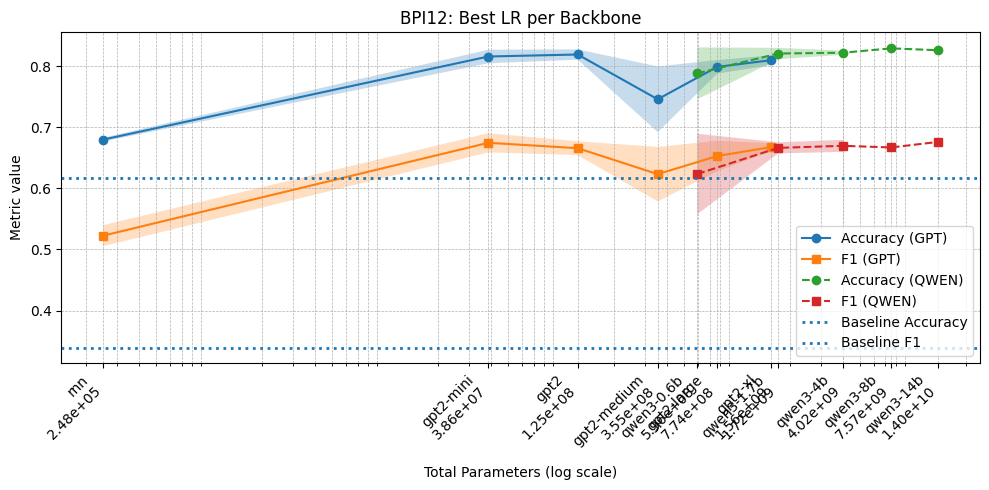

In [ ]:
plot_dataset(best_per_log_backbone, "BPI12")


In [ ]:
# COMPLETE CODE: aggregate (mean/std), pick best lr per (log, backbone) by f1_mean,
# then plot all logs in a 2-column matrix with:
#  - bottom x-axis: backbone names (diagonal)
#  - top x-axis: decade ticks labeled 1e3, 1e4, ...
#  - colors: Accuracy=blue, F1=orange
#  - line styles: GPT=solid, Qwen=dashed
#  - baseline_transition_frequency: horizontal dotted lines (acc + f1)
#  - shared/global x- and y-axis ranges across all subplots

import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def compute_log_padded_range(x_vals, pad_decades=0.15):
    xmin = np.min(x_vals)
    xmax = np.max(x_vals)

    log_min = np.log10(xmin)
    log_max = np.log10(xmax)

    log_pad = pad_decades * (log_max - log_min)
    return (
        10 ** (log_min - log_pad),
        10 ** (log_max + log_pad),
    )



# ----------------------------
# 1) Configuration
# ----------------------------
METRICS = {
    "best_test_final_next_activity_acc": "acc",
    "best_test_final_next_activity_f1": "f1",
}

GROUP_COLS = ["log", "backbone", "lr", "batch_size", "categorical_features", "continuous_features"]
EXTRA_COLS = ["total_params", "trainable_params", "embedding_size"]


# ----------------------------
# 2) Helpers
# ----------------------------
def make_hashable(x):
    """Convert unhashable objects (list/dict/set) into a stable string for grouping."""
    if pd.isna(x):
        return pd.NA
    if isinstance(x, (list, tuple)):
        return json.dumps(x, sort_keys=True)
    if isinstance(x, set):
        return json.dumps(sorted(list(x)))
    if isinstance(x, dict):
        return json.dumps(x, sort_keys=True)
    return x

def backbone_family(name: str) -> str:
    """Classify backbone into family for linestyle."""
    s = str(name)
    return "qwen" if s.startswith("qwen") else "gpt"

def add_param_top_axis_scientific(ax, xmin, xmax):
    """Top x-axis with decade ticks labeled 1e3, 1e4, ... within [xmin, xmax]."""
    ax_top = ax.twiny()
    ax_top.set_xscale("log")
    ax_top.set_xlim(xmin, xmax)

    # decade ticks only
    kmin = int(np.floor(np.log10(xmin)))
    kmax = int(np.ceil(np.log10(xmax)))
    ticks = [10**k for k in range(kmin, kmax + 1)]
    ticks = [t for t in ticks if xmin <= t <= xmax]

    ax_top.set_xticks(ticks)
    ax_top.set_xticklabels([f"1e{int(np.log10(t))}" for t in ticks])

    # place labels close to the main axis
    ax_top.tick_params(axis="x", which="major", pad=-2, length=3)
    ax_top.spines["top"].set_visible(False)
    ax_top.grid(False)
    return ax_top


# ----------------------------
# 3) Build summary with mean/std
# ----------------------------
def build_summary_with_std(runs: pd.DataFrame) -> pd.DataFrame:
    extra_cols = [c for c in EXTRA_COLS if c in runs.columns]
    tmp = runs.copy()

    # Ensure grouping columns are hashable
    for c in GROUP_COLS:
        if c in tmp.columns:
            tmp[c] = tmp[c].map(make_hashable)

    keep_cols = [c for c in GROUP_COLS if c in tmp.columns] + ["id"] + list(METRICS.keys()) + extra_cols
    df = tmp[keep_cols].copy()

    # metrics numeric
    for m in METRICS:
        df[m] = pd.to_numeric(df[m], errors="coerce")

    # keep rows with at least one metric
    df = df.dropna(subset=list(METRICS.keys()), how="all")

    # Aggregate count + mean + std (KEEP NaN groups)
    agg = (
        df.groupby(GROUP_COLS, dropna=False)
          .agg({m: ["count", "mean", "std"] for m in METRICS})
    )

    # Flatten columns -> acc_count/mean/std, f1_count/mean/std
    agg.columns = [f"{METRICS[m]}_{stat}" for (m, stat) in agg.columns]

    # Descriptors (KEEP NaN groups)
    if extra_cols:
        descriptors = df.groupby(GROUP_COLS, dropna=False)[extra_cols].first()
        summary = agg.join(descriptors)
    else:
        summary = agg

    # Best run id (choose priority metric)
    BEST_METRIC = "best_test_final_next_activity_acc"
    best_idx = df.groupby(GROUP_COLS, dropna=False)[BEST_METRIC].idxmax()
    best_runs = df.loc[best_idx].set_index(GROUP_COLS)["id"].rename("best_run_id")

    summary = summary.join(best_runs).reset_index()

    # Rename counts
    summary = summary.rename(columns={"acc_count": "acc_n_runs", "f1_count": "f1_n_runs"})

    # Ensure numeric for plotting columns
    for col in ["acc_mean", "acc_std", "f1_mean", "f1_std", "acc_n_runs", "f1_n_runs", "total_params"]:
        if col in summary.columns:
            summary[col] = pd.to_numeric(summary[col], errors="coerce")

    return summary


# ----------------------------
# 4) Select best lr per (log, backbone) by highest f1_mean
# ----------------------------
def select_best_lr_per_log_backbone(summary: pd.DataFrame) -> pd.DataFrame:
    s = summary.copy()
    s["f1_mean"] = pd.to_numeric(s["f1_mean"], errors="coerce")
    if "acc_mean" in s.columns:
        s["acc_mean"] = pd.to_numeric(s["acc_mean"], errors="coerce")

    sort_cols = ["log", "backbone", "f1_mean"]
    ascending = [True, True, False]

    # tie-breakers
    if "acc_mean" in s.columns:
        sort_cols.append("acc_mean"); ascending.append(False)
    if "f1_n_runs" in s.columns:
        sort_cols.append("f1_n_runs"); ascending.append(False)
    if "lr" in s.columns:
        sort_cols.append("lr"); ascending.append(True)

    return (
        s.sort_values(sort_cols, ascending=ascending, na_position="last")
         .groupby(["log", "backbone"], dropna=False, as_index=False)
         .head(1)
         .reset_index(drop=True)
    )


# ----------------------------
# 5) Plot matrix for all logs (2 columns)
# ----------------------------
def plot_all_logs_matrix(
    best_df: pd.DataFrame,
    ncols: int = 2,
    x_axis: str = "total_params",
    save_path: str | None = None,
    dpi: int = 300,
):

    logs = sorted(best_df["log"].dropna().unique())
    nlogs = len(logs)
    nrows = math.ceil(nlogs / ncols)

    # ---------- GLOBAL AXIS RANGES ----------
    x_vals = best_df[x_axis].dropna().astype(float).values
    global_xmin, global_xmax = compute_log_padded_range(x_vals)

    y_candidates = []
    for col in ["acc_mean", "f1_mean"]:
        if col in best_df.columns:
            y_candidates.extend(best_df[col].dropna().astype(float).values)

    if "acc_std" in best_df.columns:
        y_candidates.extend((best_df["acc_mean"] - best_df["acc_std"]).dropna().astype(float).values)
        y_candidates.extend((best_df["acc_mean"] + best_df["acc_std"]).dropna().astype(float).values)
    if "f1_std" in best_df.columns:
        y_candidates.extend((best_df["f1_mean"] - best_df["f1_std"]).dropna().astype(float).values)
        y_candidates.extend((best_df["f1_mean"] + best_df["f1_std"]).dropna().astype(float).values)

    global_ymin = float(np.min(y_candidates))
    global_ymax = float(np.max(y_candidates))
    y_pad = 0.02 * (global_ymax - global_ymin) if global_ymax > global_ymin else 0.01
    global_ymin -= y_pad
    global_ymax += y_pad

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(13, 4.7 * nrows),
        sharex=True,
        sharey=True,
    )
    axes = np.array(axes).reshape(nrows, ncols)

    ACC_COLOR = "tab:blue"
    F1_COLOR = "tab:orange"
    legend_handles = {}

    for i, log in enumerate(logs):
        r, c = divmod(i, ncols)
        ax = axes[r, c]

        data_all = best_df[best_df["log"] == log]
        baseline = data_all[data_all["backbone"] == "baseline_transition_frequency"]
        data = data_all[data_all["backbone"] != "baseline_transition_frequency"]

        # ✅ use x_axis here
        data = data.dropna(subset=[x_axis]).sort_values(x_axis)

        # GPT / QWEN
        for fam, linestyle in [("gpt", "-"), ("qwen", "--")]:
            fam_data = data[data["backbone"].map(lambda b: backbone_family(b) == fam)]
            if fam_data.empty:
                continue

            x = fam_data[x_axis].astype(float).values

            h_acc, = ax.plot(
                x, fam_data["acc_mean"],
                color=ACC_COLOR, linestyle=linestyle, marker="o",
                label=f"Accuracy ({fam.upper()})"
            )
            ax.fill_between(
                x,
                (fam_data["acc_mean"] - fam_data["acc_std"]),
                (fam_data["acc_mean"] + fam_data["acc_std"]),
                color=ACC_COLOR, alpha=0.2
            )

            h_f1, = ax.plot(
                x, fam_data["f1_mean"],
                color=F1_COLOR, linestyle=linestyle, marker="s",
                label=f"F1 ({fam.upper()})"
            )
            ax.fill_between(
                x,
                (fam_data["f1_mean"] - fam_data["f1_std"]),
                (fam_data["f1_mean"] + fam_data["f1_std"]),
                color=F1_COLOR, alpha=0.2
            )

            legend_handles.setdefault(f"Accuracy ({fam.upper()})", h_acc)
            legend_handles.setdefault(f"F1 ({fam.upper()})", h_f1)

        if not baseline.empty:
            b = baseline.iloc[0]
            if pd.notna(b.get("acc_mean", np.nan)):
                h = ax.axhline(float(b["acc_mean"]), color=ACC_COLOR, linestyle=":", linewidth=2)
                legend_handles.setdefault("Baseline Accuracy", h)
            if pd.notna(b.get("f1_mean", np.nan)):
                h = ax.axhline(float(b["f1_mean"]), color=F1_COLOR, linestyle=":", linewidth=2)
                legend_handles.setdefault("Baseline F1", h)

        ax.set_xscale("log")
        ax.set_xlim(global_xmin, global_xmax)
        ax.set_ylim(global_ymin, global_ymax)

        # ✅ use x_axis ticks too
        if not data.empty:
            xticks = data[x_axis].astype(float).values
            ax.set_xticks(xticks)
            ax.set_xticklabels(list(data["backbone"]), rotation=45, ha="right")
            ax.tick_params(axis="x", labelbottom=(r == nrows - 1))

        add_param_top_axis_scientific(ax, global_xmin, global_xmax)

        ax.set_title(str(log))
        ax.grid(True, which="both", linestyle="--", linewidth=0.5)

        if c == 0:
            ax.set_ylabel("Metric value")
        if r == nrows - 1:
            ax.set_xlabel(f"{x_axis} (log scale)")

    for j in range(nlogs, nrows * ncols):
        axes.flat[j].axis("off")

    fig.legend(
        legend_handles.values(),
        legend_handles.keys(),
        loc="upper center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, 1.02),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()








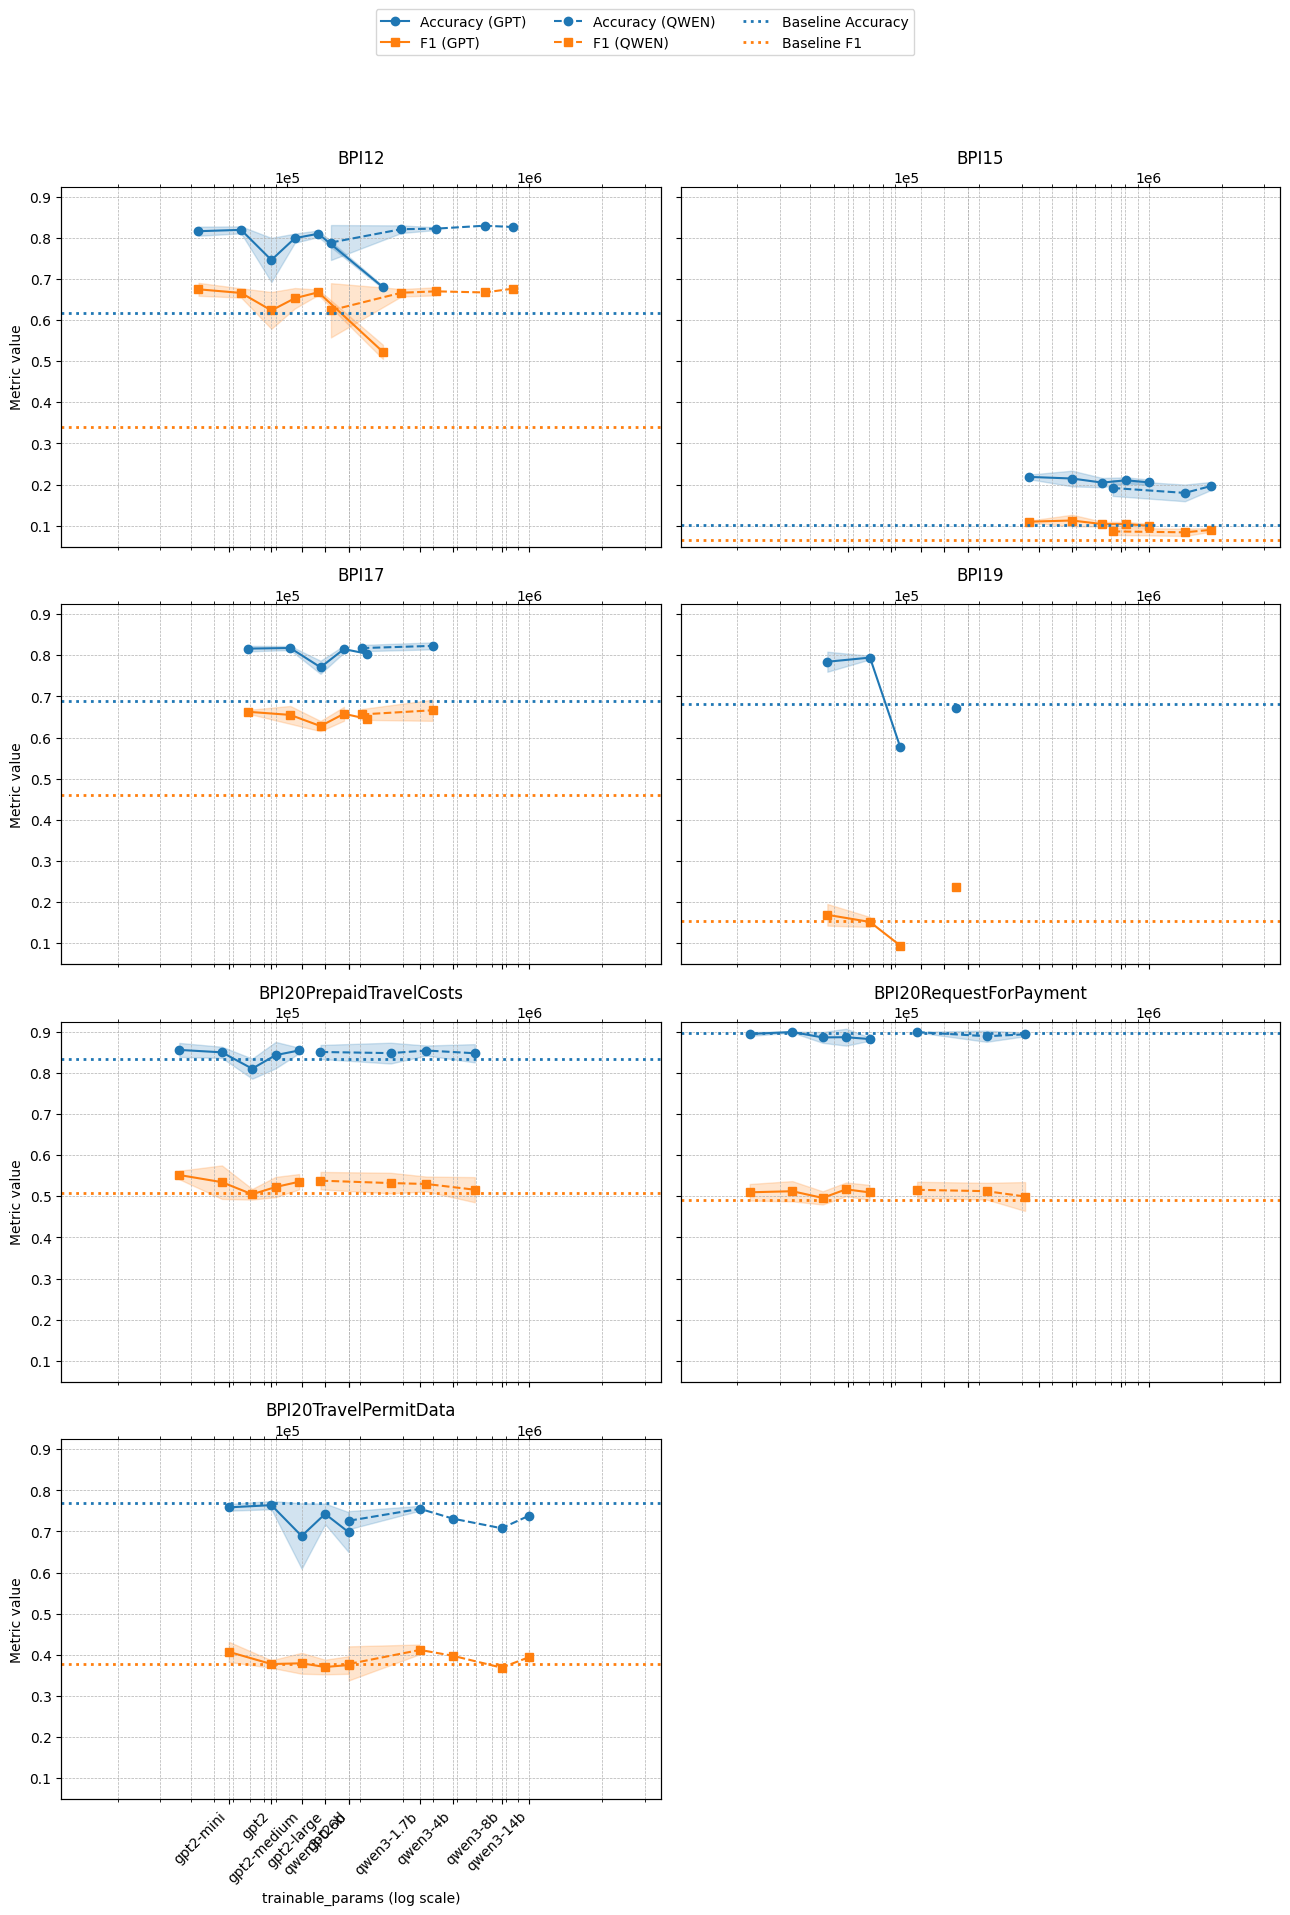

In [ ]:
# ----------------------------
# 6) RUN IT
# ----------------------------
# Assumes you already have a DataFrame named `runs`.
summary = build_summary_with_std(runs)
best_per_log_backbone = select_best_lr_per_log_backbone(summary)

save_path = plots_dir / "all_logs_trainable_params.png"

plot_all_logs_matrix(
    best_per_log_backbone,
    x_axis="trainable_params",
    save_path=str(save_path),
)

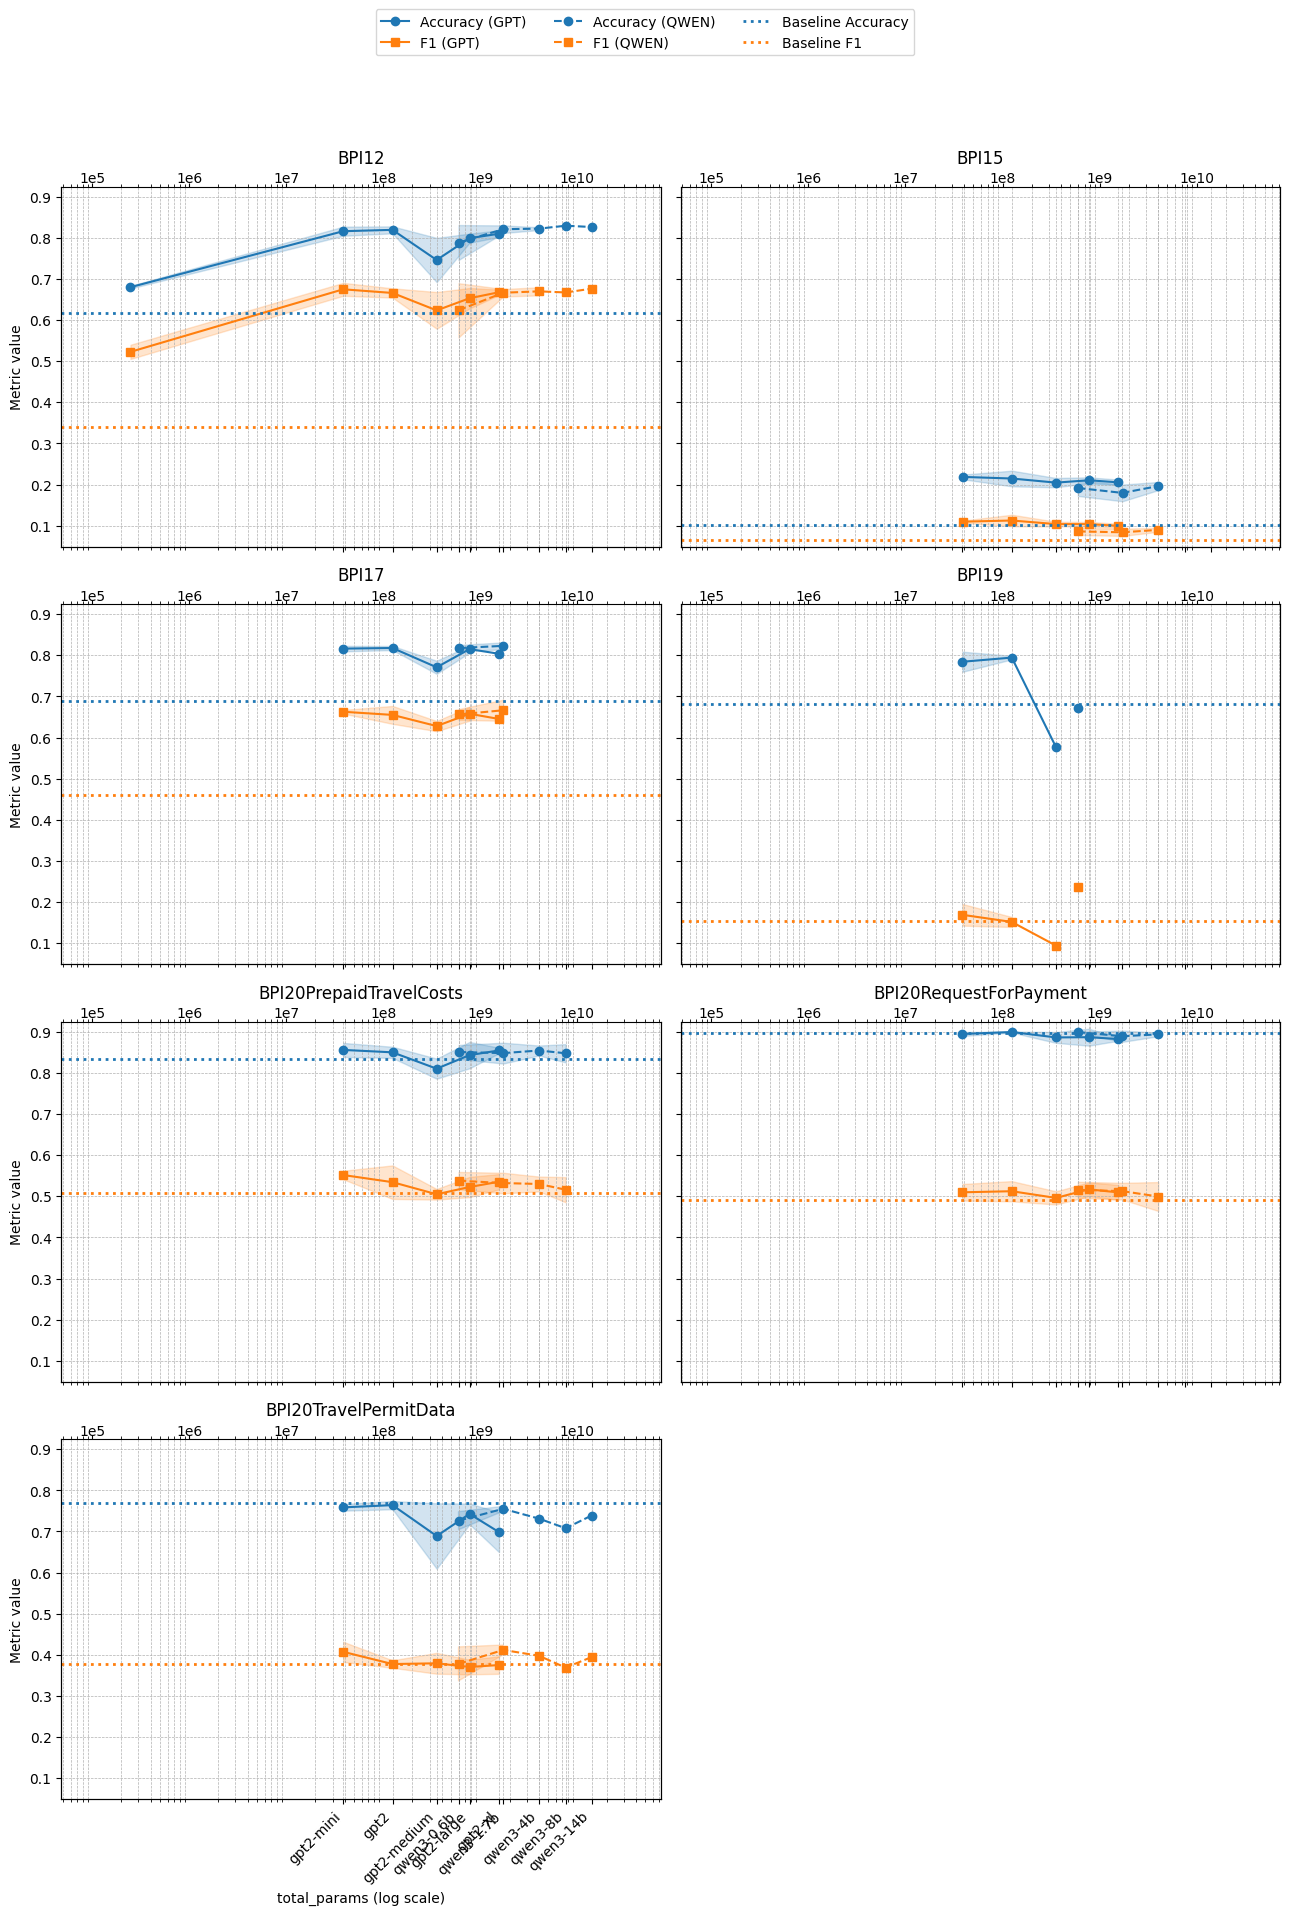

In [ ]:
save_path = plots_dir / "all_logs_total_params.png"

plot_all_logs_matrix(
    best_per_log_backbone,
    x_axis="total_params",
    save_path=str(save_path),
)

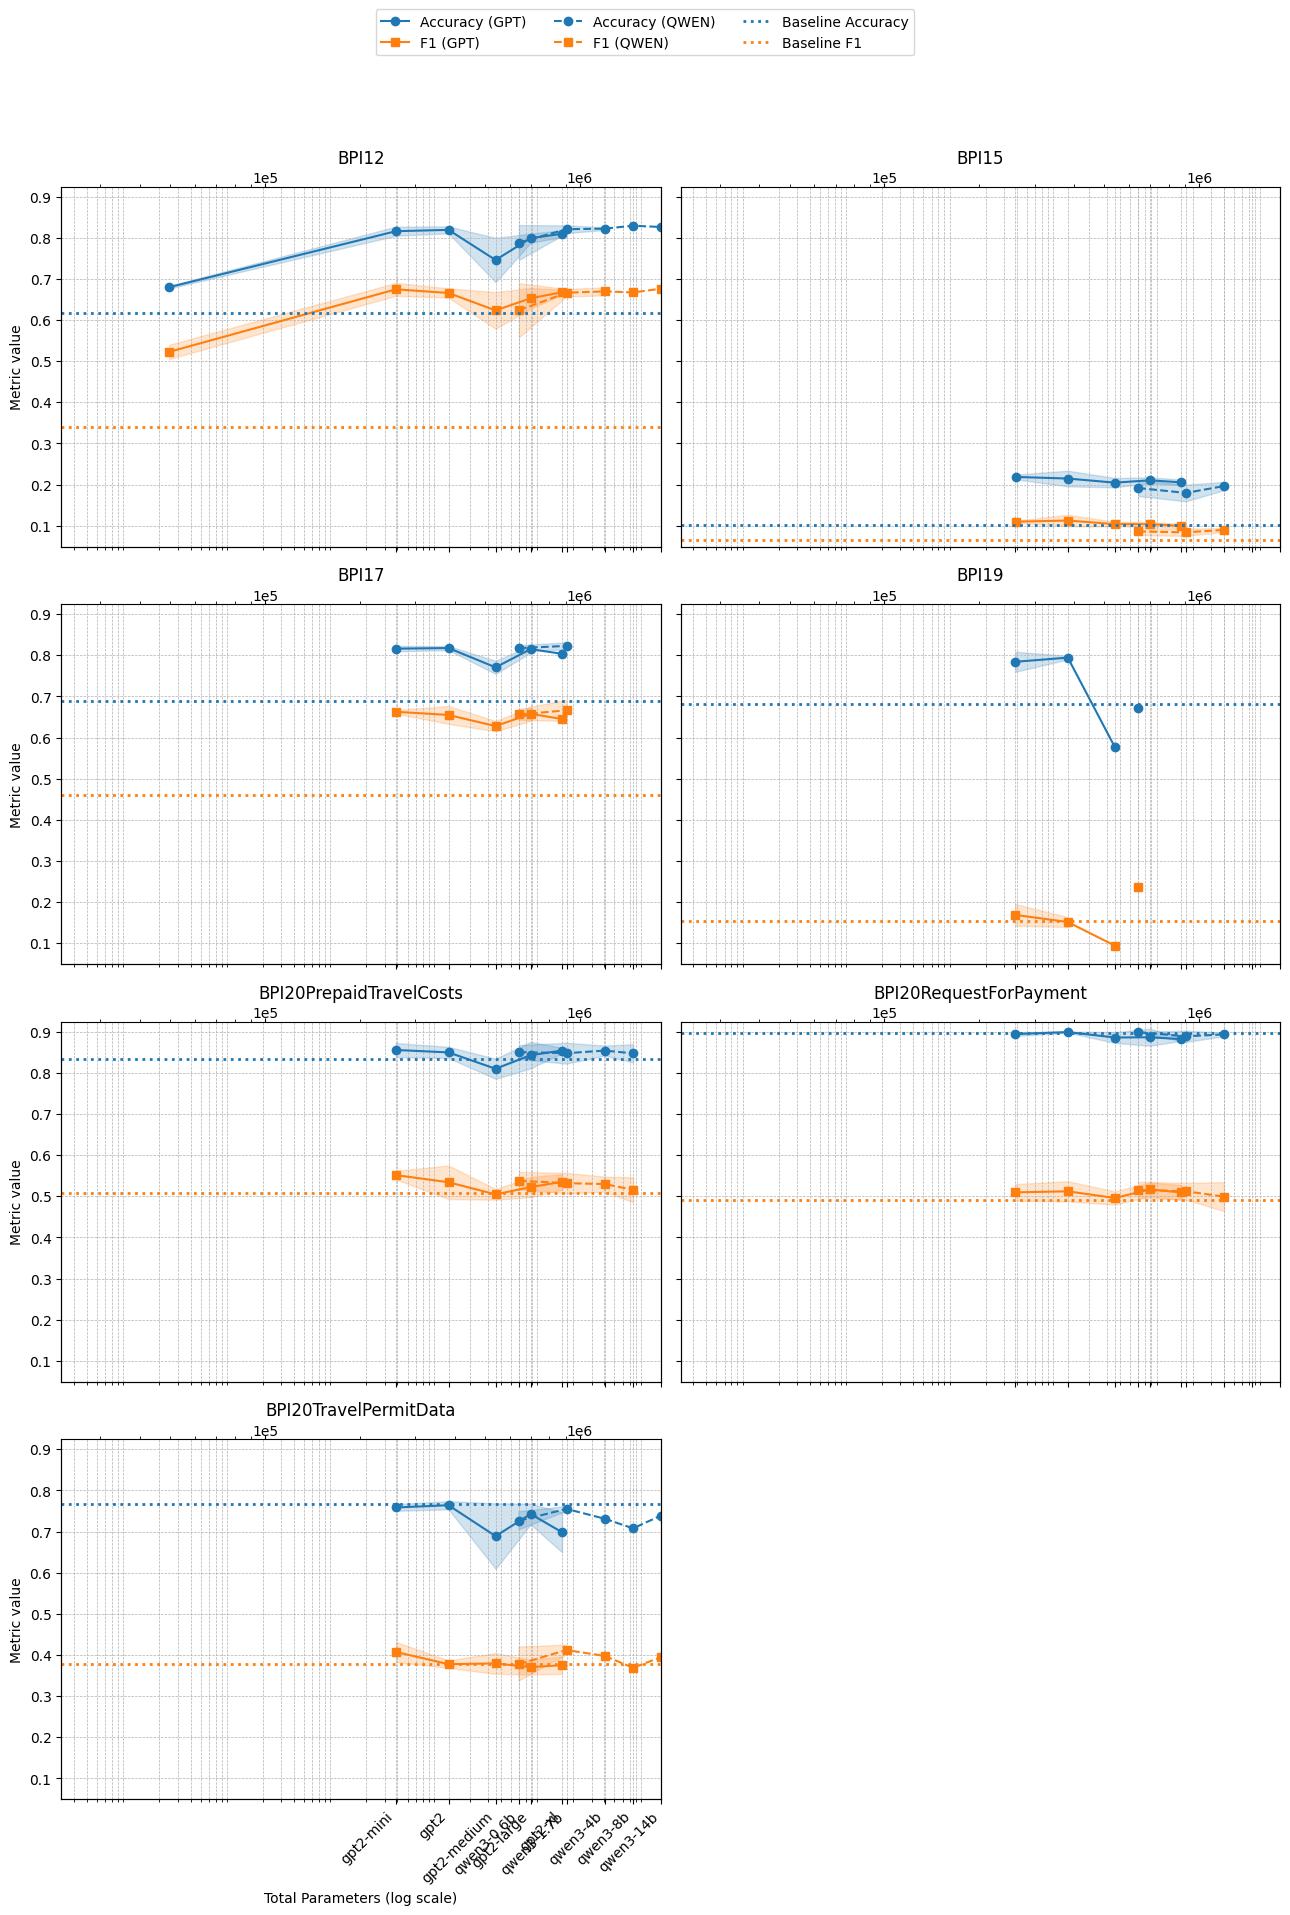

In [ ]:
# COMPLETE CODE: aggregate (mean/std), pick best lr per (log, backbone) by f1_mean,
# then plot all logs in a 2-column matrix with:
#  - bottom x-axis: backbone names (diagonal)
#  - top x-axis: decade ticks labeled 1e3, 1e4, ...
#  - colors: Accuracy=blue, F1=orange
#  - line styles: GPT=solid, Qwen=dashed
#  - baseline_transition_frequency: horizontal dotted lines (acc + f1)
#  - shared/global x- and y-axis ranges across all subplots

import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------
# 1) Configuration
# ----------------------------
METRICS = {
    "best_test_final_next_activity_acc": "acc",
    "best_test_final_next_activity_f1": "f1",
}

GROUP_COLS = ["log", "backbone", "lr", "batch_size", "categorical_features", "continuous_features"]
EXTRA_COLS = ["total_params", "trainable_params", "embedding_size"]


# ----------------------------
# 2) Helpers
# ----------------------------
def make_hashable(x):
    """Convert unhashable objects (list/dict/set) into a stable string for grouping."""
    if pd.isna(x):
        return pd.NA
    if isinstance(x, (list, tuple)):
        return json.dumps(x, sort_keys=True)
    if isinstance(x, set):
        return json.dumps(sorted(list(x)))
    if isinstance(x, dict):
        return json.dumps(x, sort_keys=True)
    return x

def backbone_family(name: str) -> str:
    """Classify backbone into family for linestyle."""
    s = str(name)
    return "qwen" if s.startswith("qwen") else "gpt"

def add_param_top_axis_scientific(ax, xmin, xmax):
    """Top x-axis with decade ticks labeled 1e3, 1e4, ... within [xmin, xmax]."""
    ax_top = ax.twiny()
    ax_top.set_xscale("log")
    ax_top.set_xlim(xmin, xmax)

    # decade ticks only
    kmin = int(np.floor(np.log10(xmin)))
    kmax = int(np.ceil(np.log10(xmax)))
    ticks = [10**k for k in range(kmin, kmax + 1)]
    ticks = [t for t in ticks if xmin <= t <= xmax]

    ax_top.set_xticks(ticks)
    ax_top.set_xticklabels([f"1e{int(np.log10(t))}" for t in ticks])

    # place labels close to the main axis
    ax_top.tick_params(axis="x", which="major", pad=-2, length=3)
    ax_top.spines["top"].set_visible(False)
    ax_top.grid(False)
    return ax_top


# ----------------------------
# 3) Build summary with mean/std
# ----------------------------
def build_summary_with_std(runs: pd.DataFrame) -> pd.DataFrame:
    extra_cols = [c for c in EXTRA_COLS if c in runs.columns]
    tmp = runs.copy()

    # Ensure grouping columns are hashable
    for c in GROUP_COLS:
        if c in tmp.columns:
            tmp[c] = tmp[c].map(make_hashable)

    keep_cols = [c for c in GROUP_COLS if c in tmp.columns] + ["id"] + list(METRICS.keys()) + extra_cols
    df = tmp[keep_cols].copy()

    # metrics numeric
    for m in METRICS:
        df[m] = pd.to_numeric(df[m], errors="coerce")

    # keep rows with at least one metric
    df = df.dropna(subset=list(METRICS.keys()), how="all")

    # Aggregate count + mean + std (KEEP NaN groups)
    agg = (
        df.groupby(GROUP_COLS, dropna=False)
          .agg({m: ["count", "mean", "std"] for m in METRICS})
    )

    # Flatten columns -> acc_count/mean/std, f1_count/mean/std
    agg.columns = [f"{METRICS[m]}_{stat}" for (m, stat) in agg.columns]

    # Descriptors (KEEP NaN groups)
    if extra_cols:
        descriptors = df.groupby(GROUP_COLS, dropna=False)[extra_cols].first()
        summary = agg.join(descriptors)
    else:
        summary = agg

    # Best run id (choose priority metric)
    BEST_METRIC = "best_test_final_next_activity_acc"
    best_idx = df.groupby(GROUP_COLS, dropna=False)[BEST_METRIC].idxmax()
    best_runs = df.loc[best_idx].set_index(GROUP_COLS)["id"].rename("best_run_id")

    summary = summary.join(best_runs).reset_index()

    # Rename counts
    summary = summary.rename(columns={"acc_count": "acc_n_runs", "f1_count": "f1_n_runs"})

    # Ensure numeric for plotting columns
    for col in ["acc_mean", "acc_std", "f1_mean", "f1_std", "acc_n_runs", "f1_n_runs", "total_params"]:
        if col in summary.columns:
            summary[col] = pd.to_numeric(summary[col], errors="coerce")

    return summary


# ----------------------------
# 4) Select best lr per (log, backbone) by highest f1_mean
# ----------------------------
def select_best_lr_per_log_backbone(summary: pd.DataFrame) -> pd.DataFrame:
    s = summary.copy()
    s["f1_mean"] = pd.to_numeric(s["f1_mean"], errors="coerce")
    if "acc_mean" in s.columns:
        s["acc_mean"] = pd.to_numeric(s["acc_mean"], errors="coerce")

    sort_cols = ["log", "backbone", "f1_mean"]
    ascending = [True, True, False]

    # tie-breakers
    if "acc_mean" in s.columns:
        sort_cols.append("acc_mean"); ascending.append(False)
    if "f1_n_runs" in s.columns:
        sort_cols.append("f1_n_runs"); ascending.append(False)
    if "lr" in s.columns:
        sort_cols.append("lr"); ascending.append(True)

    return (
        s.sort_values(sort_cols, ascending=ascending, na_position="last")
         .groupby(["log", "backbone"], dropna=False, as_index=False)
         .head(1)
         .reset_index(drop=True)
    )


# ----------------------------
# 5) Plot matrix for all logs (2 columns)
# ----------------------------
def plot_all_logs_matrix(best_df: pd.DataFrame, ncols: int = 2):
    logs = sorted(best_df["log"].dropna().unique())
    nlogs = len(logs)
    nrows = math.ceil(nlogs / ncols)

    # ---------- GLOBAL AXIS RANGES ----------
    # X range: only where total_params exists (baseline may have NaN)
    x_vals = best_df["trainable_params"].dropna().astype(float).values
    global_xmin = float(np.min(x_vals))
    global_xmax = float(np.max(x_vals))

    # Y range: include means and mean±std (baseline included via means)
    y_candidates = []
    for col in ["acc_mean", "f1_mean"]:
        if col in best_df.columns:
            y_candidates.extend(best_df[col].dropna().astype(float).values)

    if "acc_std" in best_df.columns:
        y_candidates.extend((best_df["acc_mean"] - best_df["acc_std"]).dropna().astype(float).values)
        y_candidates.extend((best_df["acc_mean"] + best_df["acc_std"]).dropna().astype(float).values)
    if "f1_std" in best_df.columns:
        y_candidates.extend((best_df["f1_mean"] - best_df["f1_std"]).dropna().astype(float).values)
        y_candidates.extend((best_df["f1_mean"] + best_df["f1_std"]).dropna().astype(float).values)

    global_ymin = float(np.min(y_candidates))
    global_ymax = float(np.max(y_candidates))
    y_pad = 0.02 * (global_ymax - global_ymin) if global_ymax > global_ymin else 0.01
    global_ymin -= y_pad
    global_ymax += y_pad

    # ---------- FIGURE ----------
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(13, 4.7 * nrows),
        sharex=True,
        sharey=True,
    )
    axes = np.array(axes).reshape(nrows, ncols)

    ACC_COLOR = "tab:blue"
    F1_COLOR = "tab:orange"
    legend_handles = {}

    for i, log in enumerate(logs):
        r, c = divmod(i, ncols)
        ax = axes[r, c]

        data_all = best_df[best_df["log"] == log]
        baseline = data_all[data_all["backbone"] == "baseline_transition_frequency"]
        data = data_all[data_all["backbone"] != "baseline_transition_frequency"]
        data = data.dropna(subset=["total_params"]).sort_values("total_params")

        # GPT / QWEN
        for fam, linestyle in [("gpt", "-"), ("qwen", "--")]:
            fam_data = data[data["backbone"].map(lambda b: backbone_family(b) == fam)]
            if fam_data.empty:
                continue

            x = fam_data["total_params"].astype(float).values

            h_acc, = ax.plot(
                x, fam_data["acc_mean"],
                color=ACC_COLOR, linestyle=linestyle, marker="o",
                label=f"Accuracy ({fam.upper()})"
            )
            ax.fill_between(
                x,
                (fam_data["acc_mean"] - fam_data["acc_std"]),
                (fam_data["acc_mean"] + fam_data["acc_std"]),
                color=ACC_COLOR, alpha=0.2
            )

            h_f1, = ax.plot(
                x, fam_data["f1_mean"],
                color=F1_COLOR, linestyle=linestyle, marker="s",
                label=f"F1 ({fam.upper()})"
            )
            ax.fill_between(
                x,
                (fam_data["f1_mean"] - fam_data["f1_std"]),
                (fam_data["f1_mean"] + fam_data["f1_std"]),
                color=F1_COLOR, alpha=0.2
            )

            legend_handles.setdefault(f"Accuracy ({fam.upper()})", h_acc)
            legend_handles.setdefault(f"F1 ({fam.upper()})", h_f1)

        # Baseline as horizontal dotted lines
        if not baseline.empty:
            b = baseline.iloc[0]
            if pd.notna(b.get("acc_mean", np.nan)):
                h = ax.axhline(float(b["acc_mean"]), color=ACC_COLOR, linestyle=":", linewidth=2)
                legend_handles.setdefault("Baseline Accuracy", h)
            if pd.notna(b.get("f1_mean", np.nan)):
                h = ax.axhline(float(b["f1_mean"]), color=F1_COLOR, linestyle=":", linewidth=2)
                legend_handles.setdefault("Baseline F1", h)

        # Shared axes
        ax.set_xscale("log")
        ax.set_xlim(global_xmin, global_xmax)
        ax.set_ylim(global_ymin, global_ymax)

        # Bottom ticks: backbone names at their x positions (diagonal)
        if not data.empty:
            xticks = data["total_params"].astype(float).values
            ax.set_xticks(xticks)
            ax.set_xticklabels(list(data["backbone"]), rotation=45, ha="right")
            # Show x tick labels on ALL bottom-row subplots (left + right)
            if r == nrows - 1:
                ax.tick_params(axis="x", labelbottom=True)
            else:
                ax.tick_params(axis="x", labelbottom=False)


        # Top axis: 1eX decade ticks (shared range)
        add_param_top_axis_scientific(ax, global_xmin, global_xmax)

        ax.set_title(str(log))
        ax.grid(True, which="both", linestyle="--", linewidth=0.5)

        # Avoid repeating axis labels
        if c == 0:
            ax.set_ylabel("Metric value")
        if r == nrows - 1:
            ax.set_xlabel("Total Parameters (log scale)")

    # Disable unused axes
    for j in range(nlogs, nrows * ncols):
        axes.flat[j].axis("off")

    fig.legend(
        legend_handles.values(),
        legend_handles.keys(),
        loc="upper center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, 1.02),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# ----------------------------
# 6) RUN IT
# ----------------------------
# Assumes you already have a DataFrame named `runs`.
summary = build_summary_with_std(runs)
best_per_log_backbone = select_best_lr_per_log_backbone(summary)

plot_all_logs_matrix(best_per_log_backbone, ncols=2)


In [ ]:
runs.columns

Index(['id', 'name', 'r', 'lr', 'log', 'device', 'epochs', 'compile',
       'backbone', 'n_layers', 'patience', 'rnn_type', 'strategy', 'val_size',
       'grad_clip', 'lifecycle', 'min_delta', 'precision', 'val_split',
       'batch_size', 'lora_alpha', 'fine_tuning', 'hidden_size', 'num_workers',
       'total_params', 'weight_decay', 'freeze_layers', 'embedding_size',
       'trainable_params', 'continuous_targets', 'categorical_targets',
       'continuous_features', 'categorical_features', 'memory_safety_margin',
       'time_positional_encoding', 'duration_sec', 'best_test_final_loss',
       'best_test_final_next_activity_acc', 'best_test_final_next_activity_f1',
       'best_test_final_next_activity_loss', 'dataset/filtered_dataset_cases',
       'dataset/filtered_dataset_end', 'dataset/filtered_dataset_events',
       'dataset/filtered_dataset_max_duration_days',
       'dataset/filtered_dataset_start', 'dataset/orig_dataset_cases',
       'dataset/orig_dataset_end', 'dataset